In [1]:
# All imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from skimage import measure, exposure
import glob
import imageio.v2 as imageio
from pathlib import Path


In [2]:
def plot_connected_components(mask, top_n):
    labeled_mask = measure.label(mask, connectivity=2)
    print(f"Number of connected components: {labeled_mask.max()}")

    # remove components that are too wide or too short relative to their width
    image_width = mask.shape[1]
    labels_to_remove = set()
    for region in measure.regionprops(labeled_mask):
        minr, minc, maxr, maxc = region.bbox
        x_extent = maxc - minc
        y_extent = maxr - minr
        # too wide (likely background) or too short (noise/artefact) or too thin (vertical borderline)
        if x_extent >= 0.75 * image_width or y_extent <= 0.3 * x_extent or x_extent <= 20:
            labels_to_remove.add(region.label)

    # zero-out the unwanted labels in one pass
    if labels_to_remove:
        for lbl in labels_to_remove:
            labeled_mask[labeled_mask == lbl] = 0

    # keep only the top_n largest remaining components
    regions = measure.regionprops(labeled_mask)
    regions = sorted(regions, key=lambda r: r.area, reverse=True)
    top_labels = [r.label for r in regions[:top_n]]

    # relabel: background=0, components=1..top_n (so values range 0..top_n)
    relabeled = np.zeros_like(labeled_mask, dtype=int)
    for i, lbl in enumerate(top_labels, start=1):
        relabeled[labeled_mask == lbl] = i

    # display with a discrete colormap so each label has a distinct color
    cmap = plt.get_cmap('nipy_spectral', top_n + 1)
    norm = colors.BoundaryNorm(np.arange(top_n + 2) - 0.5, cmap.N)
    plt.imshow(relabeled, cmap=cmap, norm=norm)
    return relabeled

In [3]:
def save_relabeled_png(relabeled, filename, out_dir='../../data/col_segmented/raw'):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = Path(out_dir) / filename

    n_labels = int(relabeled.max())
    if n_labels <= 0:
        rgba_uint8 = np.zeros(relabeled.shape + (4,), dtype=np.uint8)
        imageio.imwrite(str(out_path), rgba_uint8)
        return out_path

    steps = np.linspace(0.0, 1.0, n_labels + 1)
    colors_rgba = plt.get_cmap('rainbow')(steps)
    colors_rgba[0] = np.array([0.0, 0.0, 0.0, 0.0])

    rgba_img = colors_rgba[relabeled]
    rgba_uint8 = (rgba_img * 255).astype(np.uint8)
    imageio.imwrite(str(out_path.with_suffix('.png')), rgba_uint8, format='PNG')
    return out_path

In [4]:
files = sorted(glob.glob("../../data/col_raw/*"))

### file 0

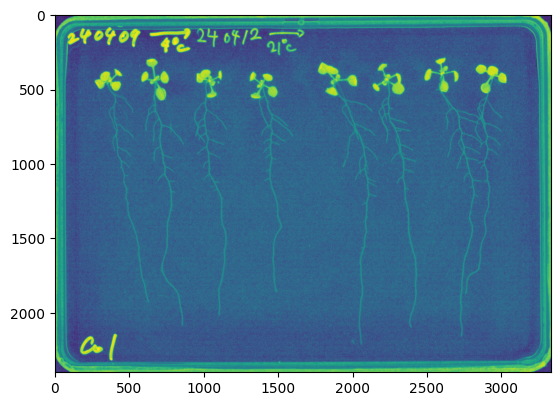

In [5]:
im = plt.imread(files[0])

if im.shape[2] == 4:
    im = im[:, :, :3]
if im.shape[2] == 3:
    im = np.average(im, axis=2, weights=[1, 1, 1])

im = exposure.rescale_intensity(im, in_range='image', out_range=(0,1))
im = exposure.equalize_adapthist(im, clip_limit=0.02)

plt.imshow(im)

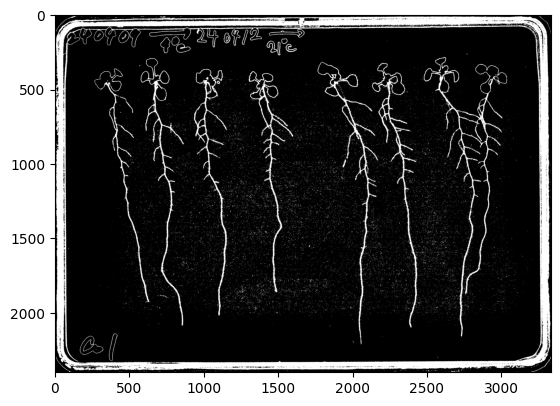

In [6]:
left_threshold_range = (0.42, 0.7)
right_threshold_range = (0.55, 0.8)

left_right_boundary = int(1 * im.shape[1])

left_im, right_im = im[:, :left_right_boundary], im[:, left_right_boundary:]
left_mask = (left_im >= left_threshold_range[0]) & (left_im <= left_threshold_range[1])
right_mask = (right_im >= right_threshold_range[0]) & (right_im <= right_threshold_range[1])
mask = np.hstack((left_mask, right_mask))

plt.imshow(mask, cmap='gray')

Number of connected components: 35470


PosixPath('../../data/col_segmented/raw/AT_240422_Col_vertical_IMG_0003.bmp')

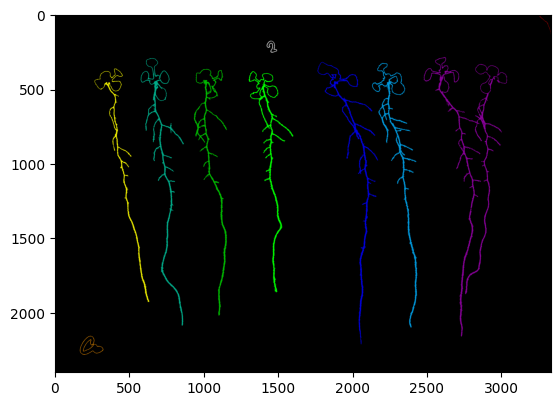

In [7]:
relabeled = plot_connected_components(mask, top_n=10)
save_relabeled_png(relabeled, filename=f'{files[0].split("/")[-1]}')

### file 1

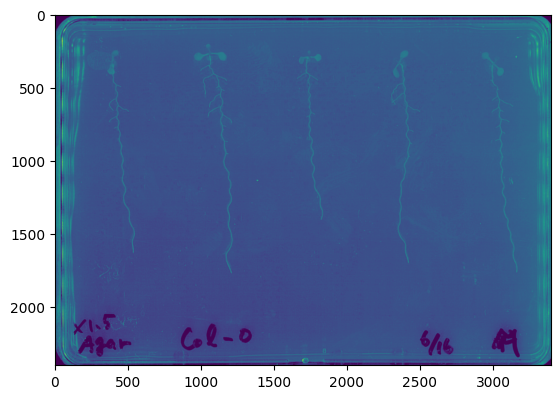

In [8]:
im = plt.imread(files[1])

if im.shape[2] == 4:
    im = im[:, :, :3]
if im.shape[2] == 3:
    im = np.average(im, axis=2, weights=[1, 1, 1])

plt.imshow(im)

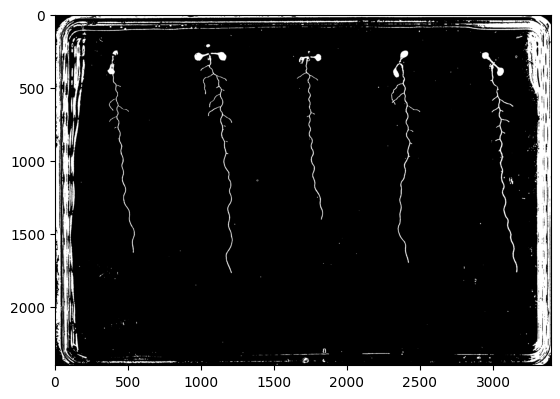

In [9]:
left_threshold_range = (90, 140)
right_threshold_range = (110, 150)

left_right_boundary = int(1 * im.shape[1])

left_im, right_im = im[:, :left_right_boundary], im[:, left_right_boundary:]
left_mask = (left_im >= left_threshold_range[0]) & (left_im <= left_threshold_range[1])
right_mask = (right_im >= right_threshold_range[0]) & (right_im <= right_threshold_range[1])
mask = np.hstack((left_mask, right_mask))

plt.imshow(mask, cmap='gray')

Number of connected components: 719


PosixPath('../../data/col_segmented/raw/Col-0_20220630112924-0001_1.0AgarTilted75.bmp')

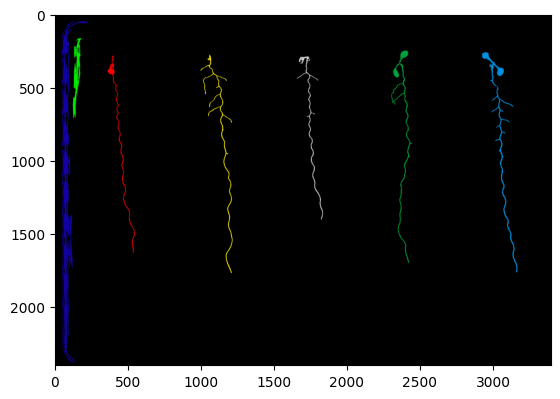

In [10]:
# pick how many components to keep (moveable parameter)
top_n = 7

relabeled = plot_connected_components(mask, top_n)
save_relabeled_png(relabeled, filename=f'{files[1].split("/")[-1]}')

### file 2

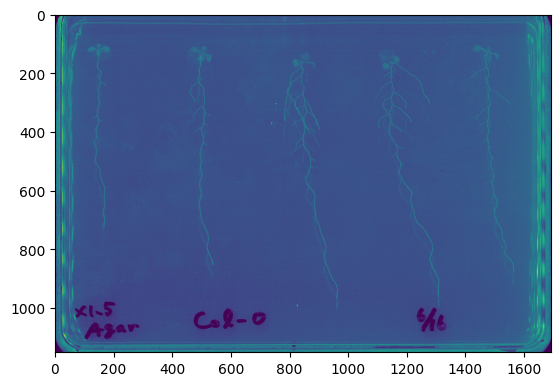

In [11]:
im = plt.imread(files[2])

plt.imshow(im)

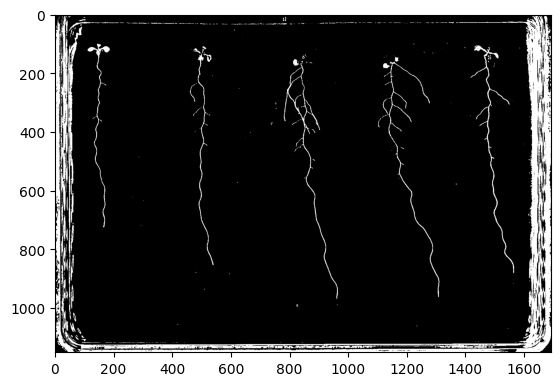

In [12]:
left_threshold_range = (90, 140)
right_threshold_range = (110, 150)

left_right_boundary = int(1 * im.shape[1])

left_im, right_im = im[:, :left_right_boundary], im[:, left_right_boundary:]
left_mask = (left_im >= left_threshold_range[0]) & (left_im <= left_threshold_range[1])
right_mask = (right_im >= right_threshold_range[0]) & (right_im <= right_threshold_range[1])
mask = np.hstack((left_mask, right_mask))

plt.imshow(mask, cmap='gray')

Number of connected components: 411


PosixPath('../../data/col_segmented/raw/Col-0_20220630112924-0001_1.0AgarVertical.tif')

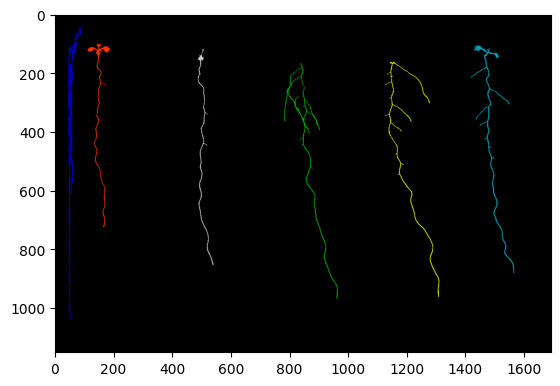

In [13]:
# pick how many components to keep (moveable parameter)
top_n = 6

relabeled = plot_connected_components(mask, top_n)
save_relabeled_png(relabeled, filename=f'{files[2].split("/")[-1]}')

### file 3

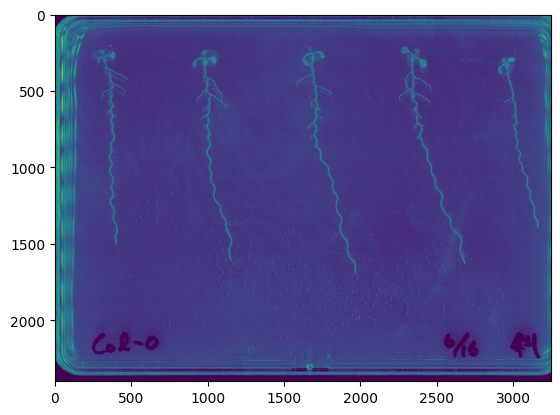

In [14]:
im = plt.imread(files[3])

if im.shape[2] == 4:
    im = im[:, :, :3]
if im.shape[2] == 3:
    im = np.average(im, axis=2, weights=[1, 1, 1])

im = exposure.rescale_intensity(im, in_range='image', out_range=(0,1))
# im = exposure.equalize_adapthist(im, clip_limit=0.02)

plt.imshow(im)

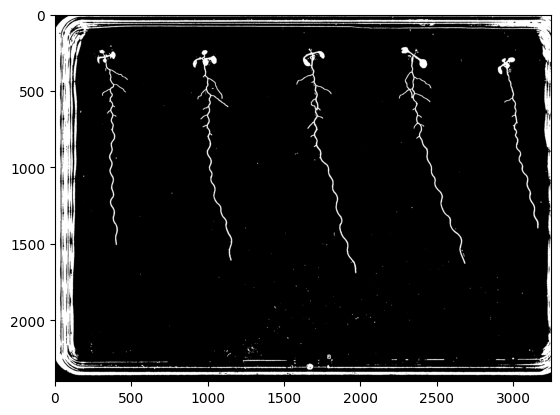

In [15]:
threshold_range = (0.3, 0.8)

mask = (im >= threshold_range[0]) & (im <= threshold_range[1])

plt.imshow(mask, cmap='gray')

Number of connected components: 412


PosixPath('../../data/col_segmented/raw/Col-0_20220630112924-0001_1.5AgarTilted75.bmp')

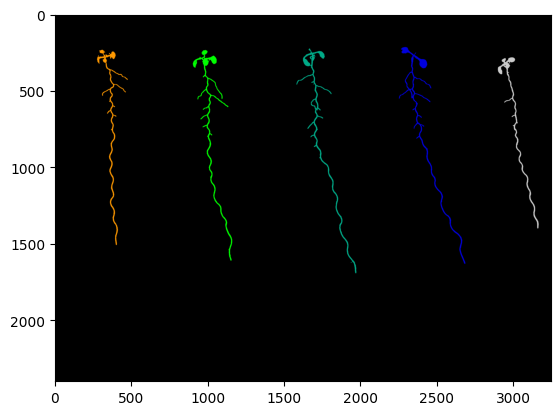

In [16]:
relabeled = plot_connected_components(mask, top_n=5)
save_relabeled_png(relabeled, filename=f'{files[3].split("/")[-1]}')

### file 4

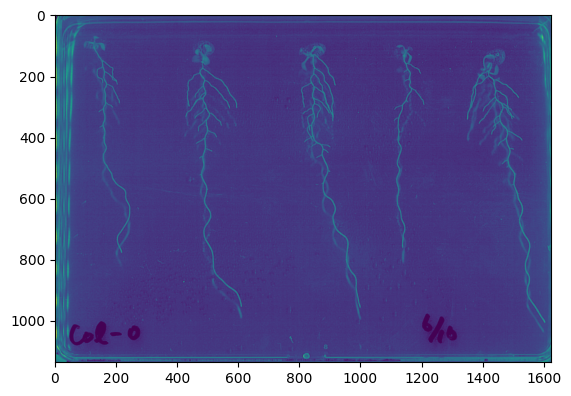

In [17]:
im = plt.imread(files[4])

plt.imshow(im)

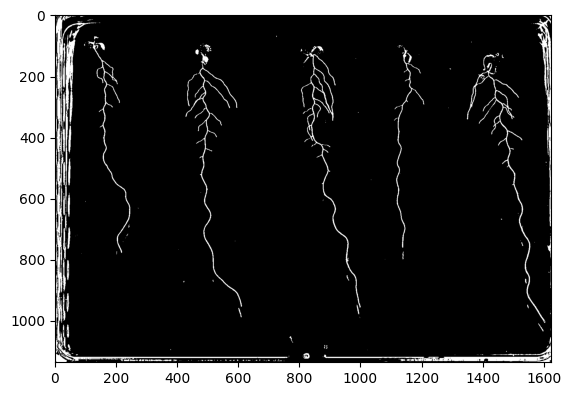

In [18]:
left_threshold_range = (85, 150)
right_threshold_range = (110, 150)

left_right_boundary = int(1 * im.shape[1])

left_im, right_im = im[:, :left_right_boundary], im[:, left_right_boundary:]
left_mask = (left_im >= left_threshold_range[0]) & (left_im <= left_threshold_range[1])
right_mask = (right_im >= right_threshold_range[0]) & (right_im <= right_threshold_range[1])
mask = np.hstack((left_mask, right_mask))

plt.imshow(mask, cmap='gray')

Number of connected components: 284


PosixPath('../../data/col_segmented/raw/Col-0_20220630112924-0001_1.5AgarVertical.tif')

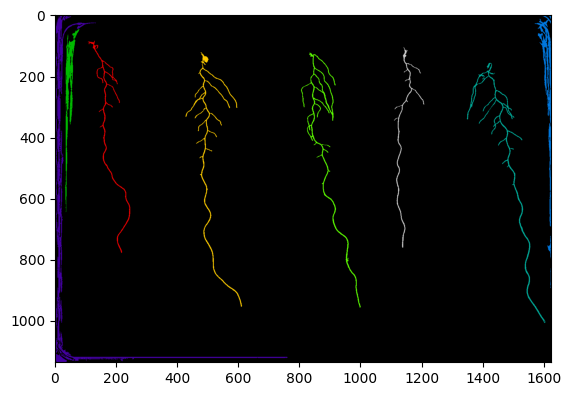

In [19]:
# pick how many components to keep (moveable parameter)
top_n = 8

relabeled = plot_connected_components(mask, top_n)
save_relabeled_png(relabeled, filename=f'{files[4].split("/")[-1]}')

### file 5

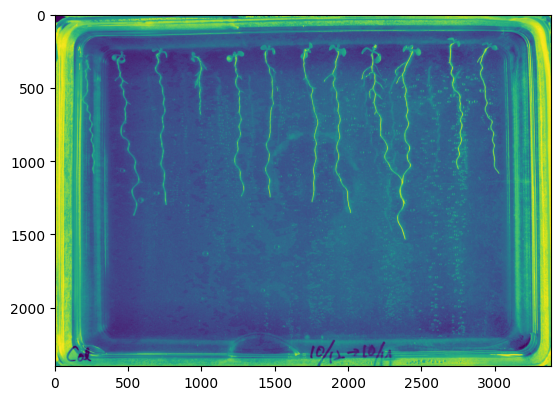

In [20]:
im = plt.imread(files[5])

if im.shape[2] == 4:
    im = im[:, :, :3]
if im.shape[2] == 3:
    im = np.average(im, axis=2, weights=[1, 0, 0])

im = exposure.rescale_intensity(im, in_range='image', out_range=(0,1))
im = exposure.equalize_adapthist(im, clip_limit=0.02)

plt.imshow(im)

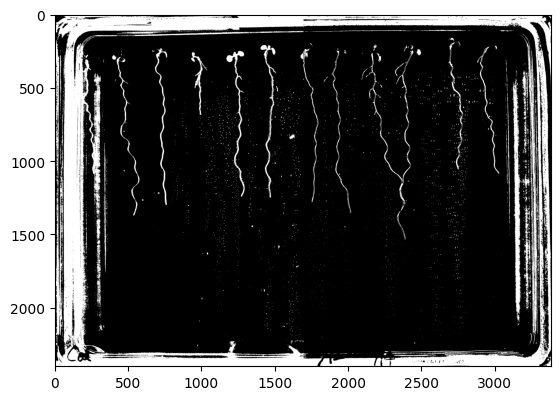

In [21]:
left_threshold_range = (0.45, 0.9)
right_threshold_range = (0.6, 0.9)

left_right_boundary = int(0.5 * im.shape[1])

left_im, right_im = im[:, :left_right_boundary], im[:, left_right_boundary:]
left_mask = (left_im >= left_threshold_range[0]) & (left_im <= left_threshold_range[1])
right_mask = (right_im >= right_threshold_range[0]) & (right_im <= right_threshold_range[1])
mask = np.hstack((left_mask, right_mask))

plt.imshow(mask, cmap='gray')

In [22]:
# kernel = np.ones((5,5), dtype=float)
# kernel[2,2] = 0
# neighbor_sum = convolve(im.astype(float), kernel, mode='constant', cval=0.0)
# neighbor_mean = neighbor_sum / 24.0
# contrast = np.abs(im - neighbor_mean)
# contrast_norm = (contrast - contrast.min()) / (contrast.max()-contrast.min()+1e-12)
# mask = contrast_norm >= 0.04
# plt.imshow(contrast_norm, cmap='grey')
# plt.imshow(mask, cmap='gray')

Number of connected components: 6418


PosixPath('../../data/col_segmented/raw/R0011536-1.bmp')

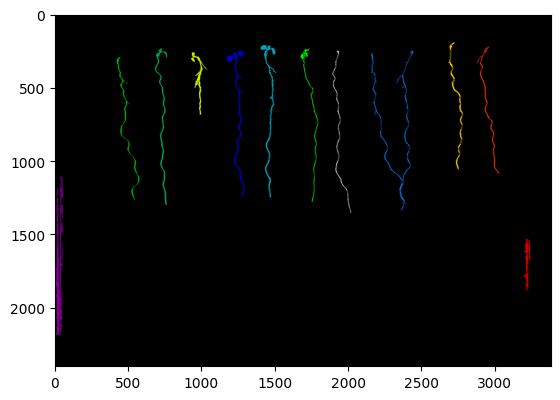

In [23]:
# pick how many components to keep (moveable parameter)
top_n = 12

relabeled = plot_connected_components(mask, top_n)
save_relabeled_png(relabeled, filename=f'{files[5].split("/")[-1]}')

### file 6

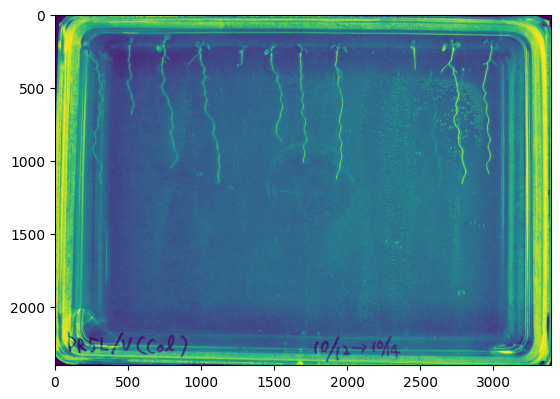

In [24]:
im = plt.imread(files[6])

if im.shape[2] == 4:
    im = im[:, :, :3]
if im.shape[2] == 3:
    im = np.average(im, axis=2, weights=[1, 1, 1])

im = exposure.rescale_intensity(im, in_range='image', out_range=(0,1))
im = exposure.equalize_adapthist(im, clip_limit=0.02)

plt.imshow(im)

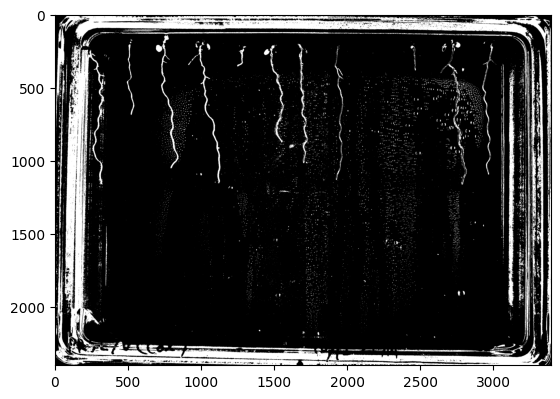

In [25]:
left_threshold_range = (0.45, 0.8)
right_threshold_range = (0.55, 0.8)

left_right_boundary = int(0.55 * im.shape[1])

left_im, right_im = im[:, :left_right_boundary], im[:, left_right_boundary:]
left_mask = (left_im >= left_threshold_range[0]) & (left_im <= left_threshold_range[1])
right_mask = (right_im >= right_threshold_range[0]) & (right_im <= right_threshold_range[1])
mask = np.hstack((left_mask, right_mask))

plt.imshow(mask, cmap='gray')

Number of connected components: 11817


PosixPath('../../data/col_segmented/raw/R0011537.bmp')

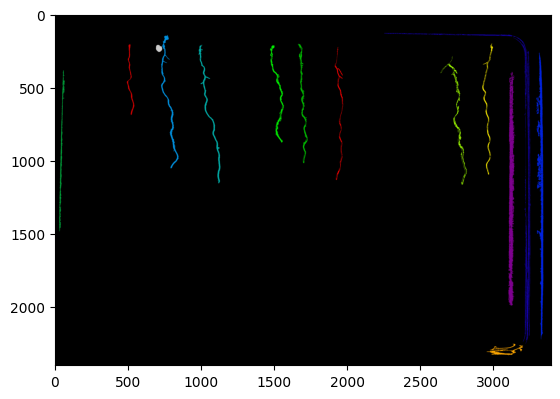

In [26]:
relabeled = plot_connected_components(mask, top_n=14)
save_relabeled_png(relabeled, filename=f'{files[6].split("/")[-1]}')

### file 7

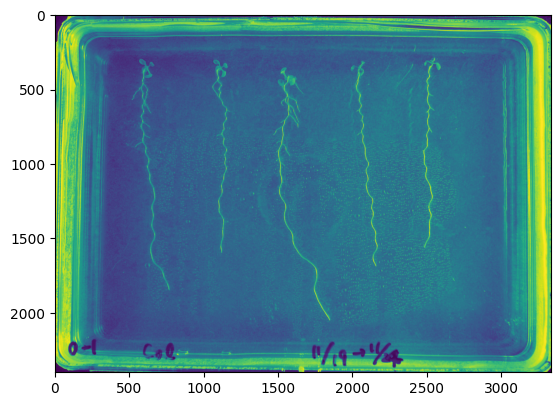

In [27]:
im = plt.imread(files[7])

if im.shape[2] == 4:
    im = im[:, :, :3]
if im.shape[2] == 3:
    im = np.average(im, axis=2, weights=[1, 1, 1])

im = exposure.rescale_intensity(im, in_range='image', out_range=(0,1))
im = exposure.equalize_adapthist(im, clip_limit=0.02)

plt.imshow(im)

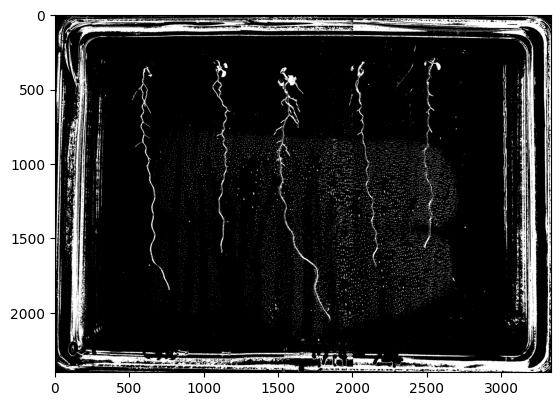

In [28]:
left_threshold_range = (0.48, 0.7)
right_threshold_range = (0.55, 0.8)

left_right_boundary = int(0.6 * im.shape[1])

left_im, right_im = im[:, :left_right_boundary], im[:, left_right_boundary:]
left_mask = (left_im >= left_threshold_range[0]) & (left_im <= left_threshold_range[1])
right_mask = (right_im >= right_threshold_range[0]) & (right_im <= right_threshold_range[1])
mask = np.hstack((left_mask, right_mask))

plt.imshow(mask, cmap='gray')

Number of connected components: 15384


PosixPath('../../data/col_segmented/raw/R0011542.bmp')

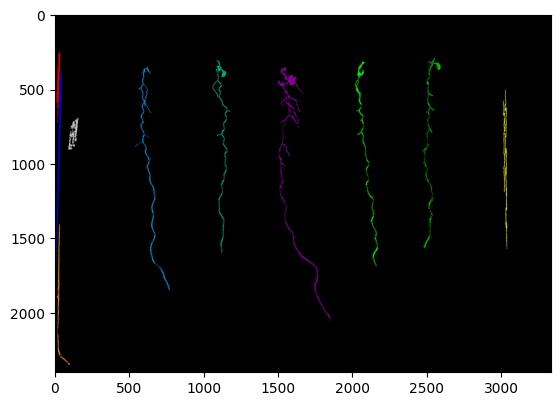

In [29]:
relabeled = plot_connected_components(mask, top_n=10)
save_relabeled_png(relabeled, filename=f'{files[7].split("/")[-1]}')